In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load data
path = r'C:\Users\PRAHARSHA\mutual_fund_analytics\data\raw\\'
processed = r'C:\Users\PRAHARSHA\mutual_fund_analytics\data\processed\\'

nav_history = pd.read_csv(processed + 'nav_history_clean.csv')
scheme_performance = pd.read_csv(path + '07_scheme_performance.csv')
benchmark_indices = pd.read_csv(path + '10_benchmark_indices.csv')

nav_history['date'] = pd.to_datetime(nav_history['date'])

print("✅ Data loaded!")
print(f"NAV History: {nav_history.shape}")
print(f"Scheme Performance: {scheme_performance.shape}")
print(f"Benchmark Indices: {benchmark_indices.shape}")

✅ Data loaded!
NAV History: (46000, 3)
Scheme Performance: (40, 19)
Benchmark Indices: (8050, 3)


In [2]:
# Step 1: Compute Daily Returns for all 40 schemes
nav_pivot = nav_history.pivot_table(index='date', columns='amfi_code', values='nav')
daily_returns = nav_pivot.pct_change().dropna()

print("✅ Daily returns computed!")
print(f"Shape: {daily_returns.shape}")
print(daily_returns.head())

✅ Daily returns computed!
Shape: (1149, 40)
amfi_code     100016    100025    100033    101206    101207    101208  \
date                                                                     
2022-01-03 -0.017467  0.014384 -0.029810  0.000890  0.006198  0.006361   
2022-01-04  0.055881  0.007797 -0.077910 -0.016922  0.020499  0.004943   
2022-01-06 -0.107497  0.021509 -0.013331  0.001374 -0.104319  0.010992   
2022-01-07 -0.045530  0.005809  0.123472  0.037795  0.113578  0.003392   
2022-01-08 -0.043225 -0.000051  0.029319  0.055318  0.118946  0.007672   

amfi_code     102885    102886    102887    118632  ...    120843    120844  \
date                                                ...                       
2022-01-03 -0.041629  0.060221  0.008050  0.026764  ...  0.059313  0.005562   
2022-01-04 -0.038595 -0.030713 -0.051257  0.066585  ... -0.087406  0.009998   
2022-01-06  0.100889  0.003876 -0.013698  0.061609  ...  0.031176  0.008328   
2022-01-07 -0.038941  0.012303 -0.084921 -

In [3]:
# Step 2: Compute CAGR for 1yr, 3yr, 5yr
cagr_results = []

for code in nav_pivot.columns:
    fund_nav = nav_pivot[code].dropna()
    if len(fund_nav) < 2:
        continue
    
    latest_nav = fund_nav.iloc[-1]
    
    def get_cagr(years):
        days = int(years * 252)
        if len(fund_nav) >= days:
            start_nav = fund_nav.iloc[-days]
            return (latest_nav / start_nav) ** (1/years) - 1
        return None
    
    scheme_name = scheme_performance[
        scheme_performance['amfi_code'] == code]['scheme_name'].values
    name = scheme_name[0] if len(scheme_name) > 0 else str(code)
    
    cagr_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'cagr_1yr': get_cagr(1),
        'cagr_3yr': get_cagr(3),
        'cagr_5yr': get_cagr(5)
    })

cagr_df = pd.DataFrame(cagr_results)
print("✅ CAGR computed!")
print(cagr_df[['scheme_name', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']].head())

✅ CAGR computed!
                                         scheme_name  cagr_1yr  cagr_3yr  \
0          HDFC Top 100 Fund - Regular Plan - Growth -0.069990 -0.003172   
1       HDFC Short Term Debt Fund - Regular - Growth  0.010032  0.045058   
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.331929  0.345226   
3      ABSL Frontline Equity Fund - Regular - Growth  0.349525  0.323801   
4             ABSL Small Cap Fund - Regular - Growth -0.149766 -0.034918   

  cagr_5yr  
0     None  
1     None  
2     None  
3     None  
4     None  


In [4]:
# Step 3: Sharpe & Sortino Ratio
Rf = 0.065 / 252  # Daily risk-free rate

ratios = []
for code in daily_returns.columns:
    returns = daily_returns[code].dropna()
    
    # Sharpe Ratio
    excess_returns = returns - Rf
    sharpe = (excess_returns.mean() / returns.std()) * np.sqrt(252)
    
    # Sortino Ratio
    downside = returns[returns < 0].std()
    sortino = (excess_returns.mean() / downside) * np.sqrt(252) if downside > 0 else None
    
    # Max Drawdown
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    ratios.append({
        'amfi_code': code,
        'sharpe_ratio': round(sharpe, 4),
        'sortino_ratio': round(sortino, 4) if sortino else None,
        'max_drawdown': round(max_drawdown, 4)
    })

ratios_df = pd.DataFrame(ratios)
print("✅ Sharpe, Sortino, Max Drawdown computed!")
print(ratios_df.head())

✅ Sharpe, Sortino, Max Drawdown computed!
   amfi_code  sharpe_ratio  sortino_ratio  max_drawdown
0     100016        0.2711         0.3398       -0.2473
1     100025       -0.0062        -0.0060       -0.0974
2     100033        0.6851         0.7080       -0.3460
3     101206        0.5706         0.6139       -0.2988
4     101207        0.4911         0.6149       -0.3553


In [6]:
# Step 4: Alpha and Beta using OLS regression
from scipy import stats

# Get Nifty 50 benchmark returns
print(benchmark_indices.columns.tolist())
print(benchmark_indices.head())

['date', 'index_name', 'close_value']
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [7]:
# Step 4: Alpha and Beta
from scipy import stats

# Get Nifty 50 returns
nifty = benchmark_indices[benchmark_indices['index_name']=='NIFTY50'].copy()
nifty['date'] = pd.to_datetime(nifty['date'])
nifty = nifty.sort_values('date').set_index('date')
nifty_returns = nifty['close_value'].pct_change().dropna()

alpha_beta = []
for code in daily_returns.columns:
    fund_ret = daily_returns[code].dropna()
    common = fund_ret.index.intersection(nifty_returns.index)
    
    if len(common) < 30:
        continue
    
    x = nifty_returns[common].values
    y = fund_ret[common].values
    
    slope, intercept, r, p, se = stats.linregress(x, y)
    
    alpha_beta.append({
        'amfi_code': code,
        'beta': round(slope, 4),
        'alpha': round(intercept * 252, 4)
    })

alpha_beta_df = pd.DataFrame(alpha_beta)
print("✅ Alpha & Beta computed!")
print(alpha_beta_df.head())

✅ Alpha & Beta computed!
   amfi_code    beta   alpha
0     100016  0.0049  0.3503
1     100025  0.0536 -0.0543
2     100033  0.2470  0.1359
3     101206  0.2026  0.0940
4     101207 -0.1089  0.3258


In [9]:
# Step 5: Fund Scorecard
scorecard = cagr_df.merge(ratios_df, on='amfi_code').merge(alpha_beta_df, on='amfi_code')

# Rank each metric
scorecard['cagr_3yr_rank'] = scorecard['cagr_3yr'].rank(ascending=False)
scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=False)
scorecard['alpha_rank'] = scorecard['alpha'].rank(ascending=False)
scorecard['expense_rank'] = scheme_performance.set_index('amfi_code')\
    .reindex(scorecard['amfi_code'])['expense_ratio_pct'].rank(ascending=True).values
scorecard['drawdown_rank'] = scorecard['max_drawdown'].rank(ascending=False)

# Composite Score (0-100)
scorecard['score'] = (
    0.30 * (1 - scorecard['cagr_3yr_rank'] / len(scorecard)) +
    0.25 * (1 - scorecard['sharpe_rank'] / len(scorecard)) +
    0.20 * (1 - scorecard['alpha_rank'] / len(scorecard)) +
    0.15 * (1 - scorecard['expense_rank'] / len(scorecard)) +
    0.10 * (1 - scorecard['drawdown_rank'] / len(scorecard))
) * 100

scorecard = scorecard.sort_values('score', ascending=False)
print("✅ Fund Scorecard created!")
print(scorecard[['scheme_name', 'cagr_3yr', 'sharpe_ratio', 'alpha', 'score']].head(10))

# Save scorecard
scorecard.to_csv(r'C:\Users\PRAHARSHA\mutual_fund_analytics\data\processed\fund_scorecard.csv', index=False)
alpha_beta_df.to_csv(r'C:\Users\PRAHARSHA\mutual_fund_analytics\data\processed\alpha_beta.csv', index=False)
print("✅ Files saved!")

✅ Fund Scorecard created!
                                          scheme_name  cagr_3yr  sharpe_ratio  \
16                Axis Midcap Fund - Regular - Growth  0.352799        0.7075   
39              DSP Small Cap Fund - Regular - Growth  0.290929        0.8611   
21         SBI Small Cap Fund - Regular Plan - Growth  0.294714        0.7995   
25           ICICI Pru Midcap Fund - Regular - Growth  0.303436        0.7466   
30             Kotak Flexicap Fund - Regular - Growth  0.283361        0.7644   
34      Mirae Asset Large Cap Fund - Regular - Growth  0.335877        0.7057   
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.345226        0.6851   
36      Mirae Asset Tax Saver Fund - Regular - Growth  0.197547        0.6703   
24          ICICI Pru Bluechip Fund - Direct - Growth  0.282317        0.5808   
32           HDFC Top 100 Fund - Direct Plan - Growth  0.177602        0.5381   

     alpha    score  
16  0.2544  74.1250  
39  0.8603  73.9375  
21  0.3612  73.6

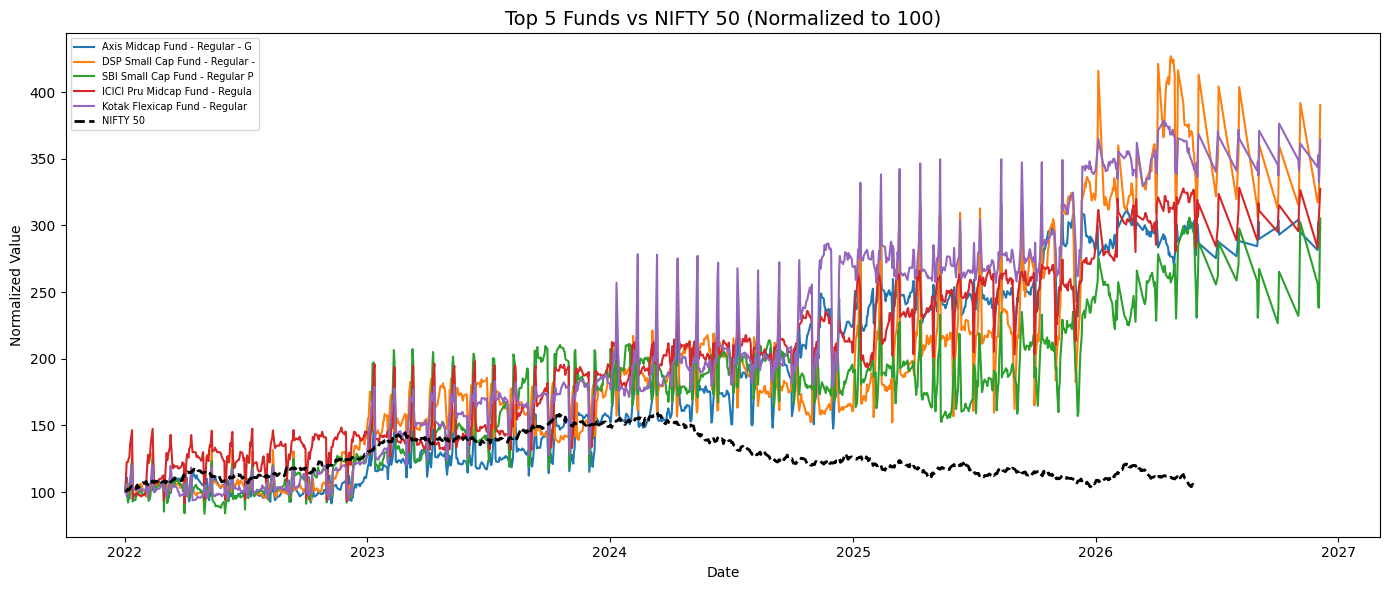

✅ Benchmark comparison chart saved!


In [10]:
# Step 6: Benchmark Comparison Chart
fig, ax = plt.subplots(figsize=(14, 6))

# Top 5 funds
top5_codes = scorecard.head(5)['amfi_code'].values
top5_names = scorecard.head(5)['scheme_name'].values

for code, name in zip(top5_codes, top5_names):
    fund_nav = nav_pivot[code].dropna()
    normalized = (fund_nav / fund_nav.iloc[0]) * 100
    ax.plot(normalized.index, normalized.values, label=name[:30])

# Nifty 50
nifty_norm = (nifty['close_value'] / nifty['close_value'].iloc[0]) * 100
ax.plot(nifty_norm.index, nifty_norm.values, label='NIFTY 50', 
        linewidth=2, linestyle='--', color='black')

ax.set_title('Top 5 Funds vs NIFTY 50 (Normalized to 100)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Value')
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(r'C:\Users\PRAHARSHA\mutual_fund_analytics\reports\benchmark_comparison.png')
plt.show()
print("✅ Benchmark comparison chart saved!")